# ARBITER walkthrough

This notebook walks through the full pipeline: a teleportation-QDS session, each attack's fingerprint, the unified and sequential detectors, the information-theoretic limits, the audit ledger, trapped-ion calibration and PKI risk scoring. Every number is computed live from the `arbiter` package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from arbiter.qds_simulation import ATTACKS, CELLS, ChannelParams, Hypothesis, SessionConfig, cell_probabilities, expected_bell_fidelity, expected_chsh, simulate_session
from arbiter.detection import SequentialDetector, UnifiedDetector, attack_bounds
from arbiter.pipeline import Arbiter

params = ChannelParams()
params

ChannelParams(visibility=0.92, storage_visibility=0.85)

## 1. Attack fingerprints

Each hypothesis induces different outcome probabilities across the observation cells: signature and freshness mismatches, four CHSH settings, and three aligned Bell-fidelity settings. The detector's likelihoods come from density matrices through the Born rule, not from tuned constants.

Note how much lower the honest mismatch rate is on the aligned `bell_*` cells than on the `chsh*` cells: the +-45 degree CHSH settings maximise the Bell *violation* and pay a factor sqrt(2) in correlator magnitude, which is exactly the information the Bell-fidelity rounds recover.

{'legitimate': {'S': 2.602, 'F': 0.94},
 'forgery': {'S': 2.602, 'F': 0.94},
 'impersonation': {'S': 0.0, 'F': 0.25},
 'replay': {'S': 0.0, 'F': 0.25},
 'channel_manipulation': {'S': 0.867, 'F': 0.48}}

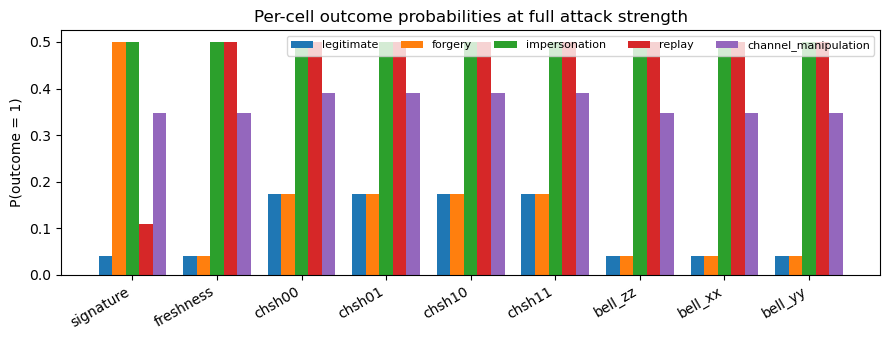

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.5))
w = 0.16
for i, h in enumerate(Hypothesis):
    ax.bar(np.arange(len(CELLS)) + (i - 2) * w, cell_probabilities(h, 1.0, params), w, label=h.value)
ax.set_xticks(range(len(CELLS)), CELLS, rotation=30, ha='right')
ax.set_ylabel('P(outcome = 1)'); ax.legend(fontsize=8, ncol=5)
ax.set_title('Per-cell outcome probabilities at full attack strength'); plt.tight_layout()
{h.value: {'S': round(expected_chsh(h, 1.0, params), 3),
           'F': round(expected_bell_fidelity(h, 1.0, params), 3)} for h in Hypothesis}

## 2. One session on real Qiskit circuits

The `qiskit` backend runs every round as an Aer circuit: Bell pair, Bell measurement, `if_test` Pauli correction and projective verification.

In [3]:
t = simulate_session(Hypothesis.REPLAY, 1.0, seed=7, backend='qiskit')
v = Arbiter().verify(t)
print(v.decision, v.attribution.value)
for r in v.reasons: print(' -', r)
v.unified.posterior

REJECT replay
 - CHSH S=0.611 below 2.0: channel integrity not certified
 - unified GLRT 431.64 > 4.35 (alpha=0.0033333333333333335); most likely: replay
 - temporal family test flagged signature, freshness, chsh (Bonferroni alpha=0.00333)


{'legitimate': 3.285917716685959e-187,
 'forgery': 1.943272812704697e-174,
 'impersonation': 2.187720641725798e-90,
 'replay': 1.0,
 'channel_manipulation': 5.314164149655659e-40}

## 3. Sequential test: raising the alarm early

Under the legitimate hypothesis the log-evidence stays below log(1/α) at every round with probability at least 1-α (Ville's inequality). Under an attack it crosses within a few dozen rounds.

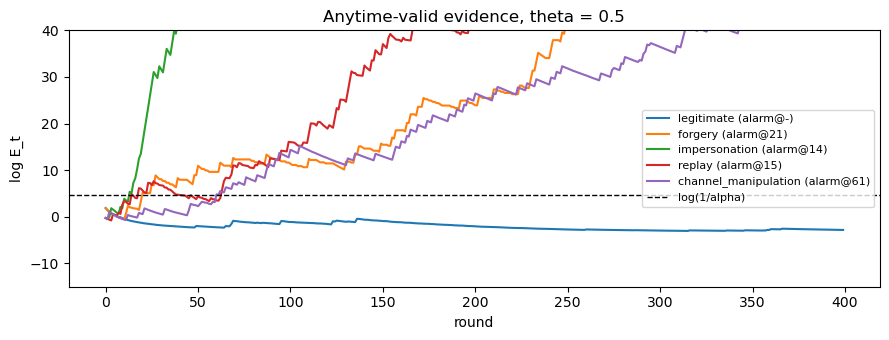

In [4]:
seq = SequentialDetector(params)
fig, ax = plt.subplots(figsize=(9, 3.5))
for h in Hypothesis:
    r = seq.evaluate(simulate_session(h, 0.5, seed=3))
    ax.plot(r.log_evidence[:400], label=f'{h.value} (alarm@{r.stopped_at if r.rejected else "-"})')
ax.axhline(np.log(100), color='k', ls='--', lw=1, label='log(1/alpha)')
ax.set_xlabel('round'); ax.set_ylabel('log E_t'); ax.set_ylim(-15, 40); ax.legend(fontsize=8)
ax.set_title('Anytime-valid evidence, theta = 0.5'); plt.tight_layout()

## 4. Accuracy across attack strengths

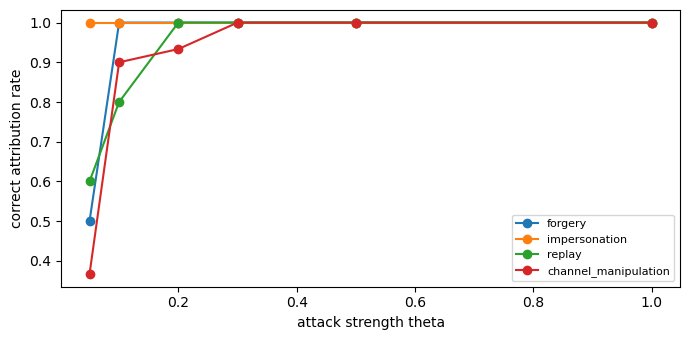

In [5]:
det = UnifiedDetector(params)
thetas = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
acc = {}
for h in ATTACKS:
    acc[h.value] = [np.mean([det.evaluate(simulate_session(h, th, seed=900 + s)).attribution is h for s in range(30)]) for th in thetas]
fig, ax = plt.subplots(figsize=(7, 3.5))
for k, a in acc.items(): ax.plot(thetas, a, 'o-', label=k)
ax.set_xlabel('attack strength theta'); ax.set_ylabel('correct attribution rate'); ax.legend(fontsize=8)
plt.tight_layout()

## 5. Information-theoretic limits

The quantum Chernoff exponent `xi_quantum` bounds every possible measurement. For forgery, ARBITER's projective Pauli measurement reaches it exactly.

For the attacks that show up on the shared pair, `xi_quantum` is **not reachable**: it is attained by a Bell-basis measurement, which is non-local and would require the signer's and verifier's halves to be in the same place. `xi_local` is the ceiling for local measurements plus classical comparison, so `local_efficiency` is the ratio that can actually be acted on -- and the Bell-fidelity rounds are what push it toward 1.

In [6]:
import pandas as pd
pd.DataFrame(attack_bounds(1.0)).set_index('attack')[['helstrom_error_single_round', 'quantum_chernoff', 'local_chernoff', 'measured_chernoff',
  'local_efficiency', 'measurement_efficiency']].round(4)

,helstrom_error_single_round,quantum_chernoff,local_chernoff,measured_chernoff,local_efficiency,measurement_efficiency
attack,,,,,,
forgery,0.3850,0.0885,0.0885,0.0885,1.0000,1.0000
impersonation,0.2298,0.2445,0.1855,0.1701,0.9167,0.6957
replay,0.3275,0.1472,0.0935,0.0794,0.8493,0.5392
channel_manipulation,0.3198,0.1207,0.0966,0.0884,0.9148,0.7326


## 6. Tamper-evident audit ledger

In [7]:
import copy
from arbiter.audit_ledger import AuditLedger, LedgerKeys, verify_entries
ledger = AuditLedger(LedgerKeys.generate(hbs_height=4))
arb = Arbiter(ledger=ledger)
for h in (Hypothesis.LEGITIMATE, Hypothesis.FORGERY): arb.verify(simulate_session(h, seed=1))
print('clean:', ledger.verify().ok)
forged = copy.deepcopy(ledger.entries)
forged[2]['payload']['decision'] = 'ACCEPT'
print('tampered:', verify_entries(forged).problems)

clean: True
tampered: ['entry 2: entry hash mismatch (content altered)']


## 7. Trapped-ion calibration

The legitimate channel can be derived from ion-trap hardware figures.

In [8]:
from arbiter.noise import PRESETS
pd.DataFrame({k: p.visibility_budget() | {'visibility': p.visibility(), 'CHSH S': 2 * np.sqrt(2) * p.visibility()} for k, p in PRESETS.items()}).round(6)

,state_of_the_art_2025,prototype,conservative
ms_gate,0.999867,0.998666,0.986665
ms_overrotation,1.000000,1.000000,0.999998
idle_dephasing,0.999860,0.984173,0.823379
amplitude_damping,0.999993,0.986799,0.936558
motional_heating,0.999867,0.999733,0.997335
crosstalk,0.999933,0.999867,0.998667
single_qubit_gates,0.999920,0.999600,0.996006
spam,0.999600,0.999000,0.994000
visibility,0.999040,0.968140,0.750262
CHSH S,2.825713,2.738314,2.122063


## 8. PKI quantum-risk scoring

In [9]:
from datetime import datetime, timedelta, timezone
from arbiter.pki_risk_scoring import assess_key
now = datetime.now(timezone.utc)
rows = [assess_key(a, b, expires=now + timedelta(days=d)).to_dict() for a, b, d in [('RSA', 1024, 365), ('RSA', 2048, 365), ('RSA', 4096, 365 * 12), ('ECDSA', 256, 90), ('Ed25519', None, 730), ('ML-DSA-65', None, 3650)]]
pd.DataFrame(rows)[['algorithm', 'key_bits', 'shor_logical_qubits', 'mosca_violated', 'score', 'level']]

,algorithm,key_bits,shor_logical_qubits,mosca_violated,score,level
0,RSA,1024.0,2051.0,False,95,critical
1,RSA,2048.0,4099.0,False,46,medium
2,RSA,4096.0,8195.0,True,85,high
3,ECDSA,256.0,2330.0,False,44,medium
4,Ed25519,255.0,2321.0,False,48,medium
5,ML-DSA-65,NaN,NaN,False,5,low
